# Model Comparison & Evaluation

## Purpose

This notebook provides a **unified comparison** of all models trained in this project. Rather than evaluating each model in isolation, this notebook loads all saved models and evaluates them on the same test set, making it easy to draw conclusions about which approach works best for campus building classification.

---

## Models compared

| Notebook | Model file | Description |
|----------|-----------|-------------|
| `01_baseline_model_CNN.ipynb` | `baseline_cnn_best.keras` | Custom CNN trained from scratch |
| `02_baseline_model_MobileNetV2.ipynb` | `baseline_mobilenetv2_best.keras` | Frozen MobileNetV2, no augmentation |
| `03_finetuned_MobileNetV2.ipynb` | `finetuned_mobilenetv2_best.keras` | Fine-tuned MobileNetV2, no augmentation |
| `04_augmented_finetuned_MobileNetV2.ipynb` | `aug_finetuned_mobilenetv2_best.keras` | Fine-tuned MobileNetV2 with augmentation |

---

## What this notebook covers

| Step | Description |
|------|-------------|
| 1. Setup & Imports | Libraries, paths, and data loading |
| 2. Load Data | Get test set via `src.preprocessing` |
| 3. Accuracy Comparison | Table and bar chart of test accuracy per model |
| 4. Confusion Matrices | Per-model confusion matrix to identify which buildings are misclassified |
| 5. Conclusions | Summary of findings |

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, str(Path().resolve().parent))

from src.preprocessing import get_datasets, IMAGE_SIZE, BATCH_SIZE, RANDOM_SEED

MODELS_DIR = Path().resolve().parent / "models"

print("Models directory:  ", MODELS_DIR.resolve())

TensorFlow version: 2.16.2
Models directory:   /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models


## 2. Load Data

The same test set is used to evaluate all models, ensuring a fair and consistent comparison.

In [2]:
train_ds, val_ds, test_ds, class_names = get_datasets()

NUM_CLASSES = len(class_names)

print(f"Classes ({NUM_CLASSES}): {class_names}")
print(f"Test batches:    {len(test_ds)}")

Classes (8): ['2', '3', '4', '5', '7', '8', '9', '10']
Test batches:    6


2026-04-13 15:19:05.384845: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-13 15:19:05.384867: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-13 15:19:05.384873: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-04-13 15:19:05.384889: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-13 15:19:05.384899: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 3. Accuracy Comparison

All models are evaluated on the test set. Results are displayed as a table and a bar chart for easy visual comparison.

In [3]:
models_to_compare = {
    "Baseline CNN":                  "baseline_cnn_best.keras",
    "Baseline MobileNetV2":          "baseline_mobilenetv2_best.keras",
    "Fine-Tuned MobileNetV2":        "finetuned_mobilenetv2_best.keras",
    "Aug + Fine-Tuned MobileNetV2":  "aug_finetuned_mobilenetv2_best.keras",
}

results = {}

print(f"{'Model':<35} {'Loss':>8}  {'Accuracy':>10}")
print("-" * 57)

for label, filename in models_to_compare.items():
    model_path = MODELS_DIR / filename
    loaded_model = tf.keras.models.load_model(model_path)
    loss, acc = loaded_model.evaluate(test_ds, verbose=0)
    results[label] = {"loss": loss, "accuracy": acc}
    print(f"{label:<35} {loss:>8.4f}  {acc * 100:>9.2f}%")

Model                                   Loss    Accuracy
---------------------------------------------------------


2026-04-13 15:19:05.773160: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Baseline CNN                          0.7072      81.52%
Baseline MobileNetV2                  0.2260      94.02%
Fine-Tuned MobileNetV2                0.2231      94.02%
Aug + Fine-Tuned MobileNetV2          0.2559      92.93%


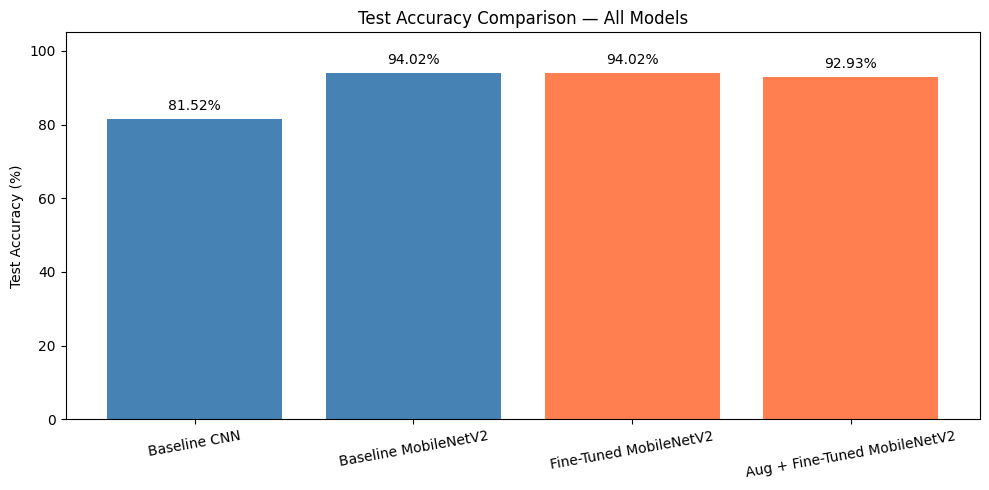

In [4]:
# Bar chart of test accuracy per model
fig, ax = plt.subplots(figsize=(10, 5))

labels   = list(results.keys())
accuracy = [results[l]["accuracy"] * 100 for l in labels]
colors   = ["steelblue", "steelblue", "coral", "coral"]

bars = ax.bar(labels, accuracy, color=colors)
ax.bar_label(bars, fmt="%.2f%%", padding=4, fontsize=10)

ax.set_ylim(0, 105)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy Comparison — All Models")
ax.tick_params(axis="x", labelrotation=10)

plt.tight_layout()
plt.show()

## 4. Confusion Matrices

A confusion matrix shows for each true class (row) how many images were predicted as each class (column). The diagonal represents correct predictions — off-diagonal entries are mistakes.

This is useful for identifying:
- Which buildings the model confuses most often
- Whether certain building pairs are consistently mixed up across models
- Which classes benefit most from fine-tuning or augmentation

2026-04-13 15:20:01.872364: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-13 15:20:10.145431: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-04-13 15:20:18.125408: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-04-13 15:20:28.545034: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


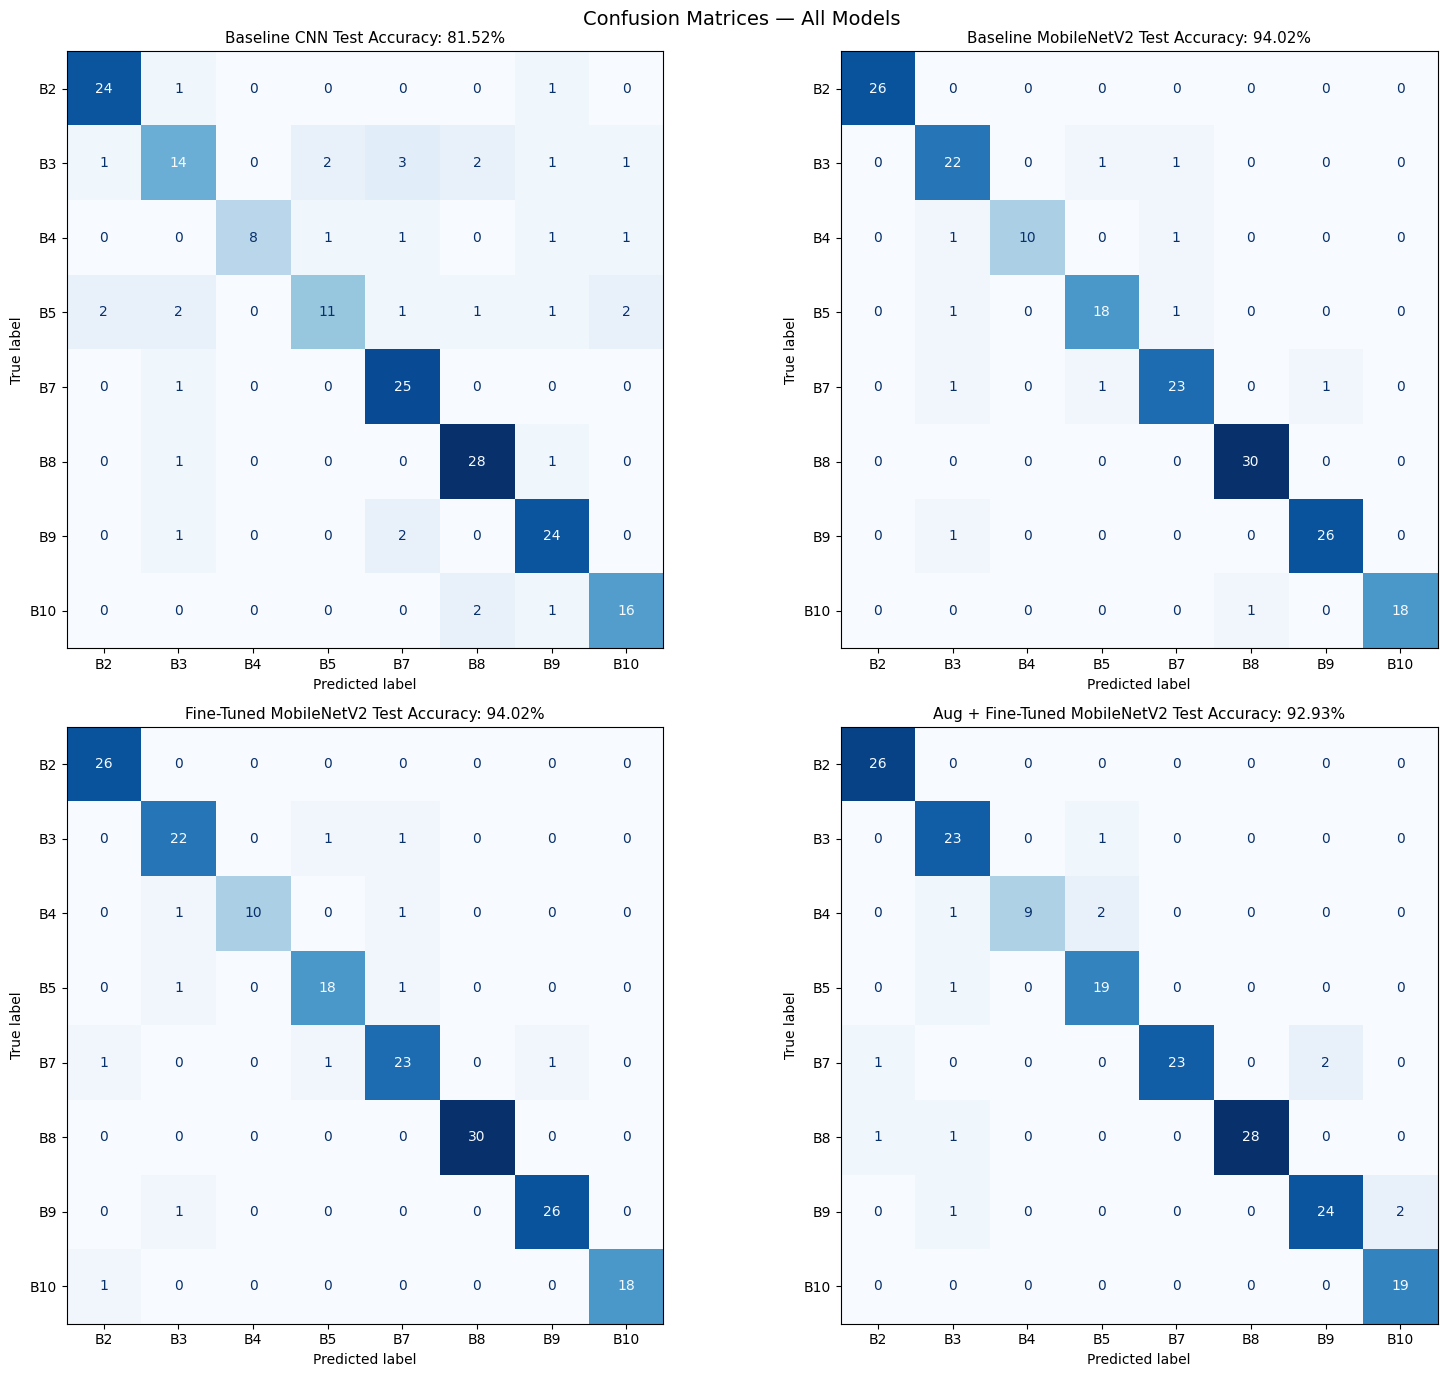

In [6]:
def get_predictions(model_path):
    """Load a model and collect all predictions and true labels from the test set."""
    model = tf.keras.models.load_model(model_path)
    all_preds  = []
    all_labels = []
    for batch_images, batch_labels in test_ds:
        preds = model.predict(batch_images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(batch_labels.numpy())
    return np.array(all_labels), np.array(all_preds)


fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (label, filename) in enumerate(models_to_compare.items()):
    true_labels, pred_labels = get_predictions(MODELS_DIR / filename)

    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f"B{n}" for n in class_names]
    )
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    acc = results[label]["accuracy"] * 100
    axes[i].set_title(f"{label} Test Accuracy: {acc:.2f}%", fontsize=11)

plt.suptitle("Confusion Matrices — All Models", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Conclusions

### Results summary

| Model | Loss | Accuracy |
|-------|------|----------|
| Baseline CNN | 0.7072 | 81.52% |
| Baseline MobileNetV2 | 0.2260 | 94.02% |
| Fine-Tuned MobileNetV2 | 0.2231 | 94.02% |
| Aug + Fine-Tuned MobileNetV2 | 0.2559 | 92.93% |

### Key findings

**Transfer learning dominates** — the gap between the custom CNN (81.52%) and any MobileNetV2 variant (92–94%) confirms that pretrained ImageNet features are highly effective for building classification, even on a small dataset of ~1,253 images.

**Fine-tuning matched but did not exceed the baseline** — the fine-tuned model achieved the same test accuracy (94.02%) as the frozen baseline, with a marginally lower loss (0.2231 vs 0.2260). This suggests the frozen ImageNet features were already well-suited to campus buildings and fine-tuning provided no meaningful gain on this dataset.

**Augmentation hurt rather than helped** — the augmented + fine-tuned model scored lower (92.93%) than both frozen and fine-tuned variants. With only ~877 training images, augmentation made training harder without providing enough diversity benefit to recover the difference.

### Recommended model for deployment

**`baseline_mobilenetv2_best.keras`** — the frozen baseline MobileNetV2 from `02_baseline_model_MobileNetV2.ipynb`.

- Tied for highest accuracy (94.02%)
- Simplest architecture — no fine-tuned layers, no augmentation
- Faster to retrain if new building data is collected
- Easiest to convert to Core ML for iOS deployment
